In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt


In [4]:
# Load Excel file
df = pd.read_excel(r"C:\Users\EDSEL\Desktop\environmental_dataset_linear_spaced (5).xlsx")

# Display first rows
df.head()


,Sample_ID,Category_Label,Temperature_Value,Humidity_Value,AQI_Value (PM2.5)
0,1,0,20.000,40.00,0.0
1,2,0,20.024,40.12,0.1
2,3,0,20.048,40.24,0.2
3,4,0,20.072,40.36,0.3
4,5,0,20.096,40.48,0.4


In [10]:
# Features
X = df[['Temperature_Value', 'Humidity_Value', 'AQI_Value (PM2.5)']]

# Target class
y = df['Category_Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [11]:
dt_model = DecisionTreeClassifier(
    criterion='gini',     # or 'entropy'
    max_depth=5,          # limit depth to avoid overfitting
    random_state=42
)


In [12]:
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50
           2       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



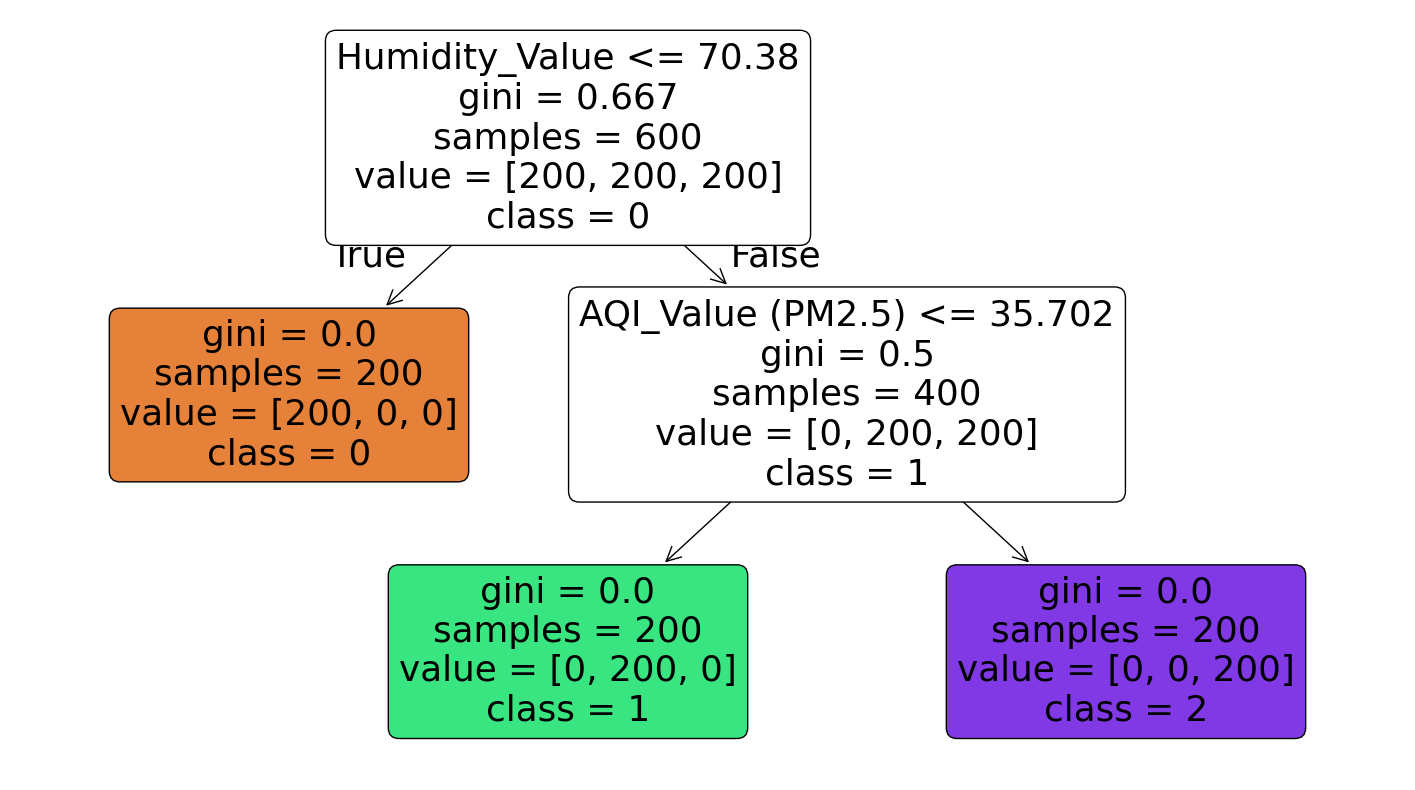

In [13]:
plt.figure(figsize=(18, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=[str(c) for c in dt_model.classes_],
    filled=True,
    rounded=True
)
plt.show()


In [15]:
# Example new data
new_data = pd.DataFrame({
    'Temperature_Value': [32],
    'Humidity_Value': [65],
    'AQI_Value (PM2.5)': [85]
})

prediction = dt_model.predict(new_data)[0]

# Mapping
label_map = {
    0: "Normal",
    1: "Moderate",
    2: "High"
}

print("Predicted Category:", label_map[prediction])


Predicted Category: Normal


# SAVING THE MODEL

In [16]:
import joblib

# Save the trained model
joblib.dump(dt_model, "environment_dt_model.joblib")

print("Model saved successfully.")


Model saved successfully.


# LOADING THE MODEL 

In [9]:
import joblib

# Load trained model
dt_model = joblib.load("environment_dt_model.joblib")

print("Model loaded successfully.")


Model loaded successfully.


# PREDICTION USING DATA FROM ARDUINO

In [ ]:
import serial
import pandas as pd
import time
import joblib

# Load model
dt_model = joblib.load("environment_dt_model.joblib")

# Label mapping
label_map = {0: "Normal", 1: "Moderate", 2: "High"}

# Serial setup
ser = serial.Serial('COM6', 9600, timeout=1)
time.sleep(2)

print("Waiting for sensor data...")

while True:
    line = ser.readline().decode('utf-8').strip()

    if not line or line.startswith("index"):
        continue

    try:
        _, temp, hum, aqi = line.split(",")

        new_data = pd.DataFrame({
            'Temperature_Value': [float(temp)],
            'Humidity_Value': [float(hum)],
            'AQI_Value': [float(aqi)]
        })

        pred = dt_model.predict(new_data)[0]
        print("Predicted Category:", label_map[pred])

    except Exception as e:
        print("Parse error:", e)


Waiting for sensor data...
Parse error: too many values to unpack (expected 4)


In [7]:
conda install -c conda-forge pyserial

Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\EDSEL\anaconda3

  added / updated specs:
    - pyserial


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.2.25  |       h4c7d964_0         144 KB  conda-forge
    certifi-2026.2.25          |     pyhd8ed1ab_0         148 KB  conda-forge
    conda-26.1.1               |  py313hfa70ccb_0         1.2 MB  conda-forge
    openssl-3.6.1              |       hf411b9b_1         8.9 MB  conda-forge
    pyserial-3.5               |     pyhcf101f3_2          72 KB  conda-forge
    ------------------------------------------------------------
                                           Total:        10.5 MB

The following NEW packages will be INSTALLED:

  pyserial    



==> WARNING: A newer version of conda exists. <==
    current version: 25.11.0
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda


